In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
sns.set_theme(style="whitegrid")
plt.rcParams['axes.unicode_minus'] = False

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')
sample_submission = pd.read_csv('../data/sample_submission.csv')

print(f"Train sets: {train.shape}")
print(f"Test sets: {test.shape}")
train.head()

Train sets: (630000, 13)
Test sets: (270000, 12)


,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.910,98.800,no,4.900,average,online videos,low,easy,78.300
1,1,18,other,diploma,4.950,94.800,yes,4.700,poor,self-study,medium,moderate,46.700
2,2,20,female,b.sc,4.680,92.600,yes,5.800,poor,coaching,high,moderate,99.000
3,3,19,male,b.sc,2.000,49.500,yes,8.300,average,group study,high,moderate,63.900
4,4,23,male,bca,7.650,86.900,yes,9.600,good,self-study,high,easy,100.000


In [4]:
print(train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                630000 non-null  int64  
 1   age               630000 non-null  int64  
 2   gender            630000 non-null  object 
 3   course            630000 non-null  object 
 4   study_hours       630000 non-null  float64
 5   class_attendance  630000 non-null  float64
 6   internet_access   630000 non-null  object 
 7   sleep_hours       630000 non-null  float64
 8   sleep_quality     630000 non-null  object 
 9   study_method      630000 non-null  object 
 10  facility_rating   630000 non-null  object 
 11  exam_difficulty   630000 non-null  object 
 12  exam_score        630000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 62.5+ MB
None


In [5]:
print(train.describe())

              id        age  study_hours  class_attendance  sleep_hours  \
count 630000.000 630000.000   630000.000        630000.000   630000.000   
mean  314999.500     20.546        4.002            71.987        7.073   
std   181865.479      2.260        2.360            17.430        1.745   
min        0.000     17.000        0.080            40.600        4.100   
25%   157499.750     19.000        1.970            57.000        5.600   
50%   314999.500     21.000        4.000            72.600        7.100   
75%   472499.250     23.000        6.050            87.200        8.600   
max   629999.000     24.000        7.910            99.400        9.900   

       exam_score  
count  630000.000  
mean       62.507  
std        18.917  
min        19.599  
25%        48.800  
50%        62.600  
75%        76.300  
max       100.000  


In [6]:
print(train.isnull().sum())

id                  0
age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64


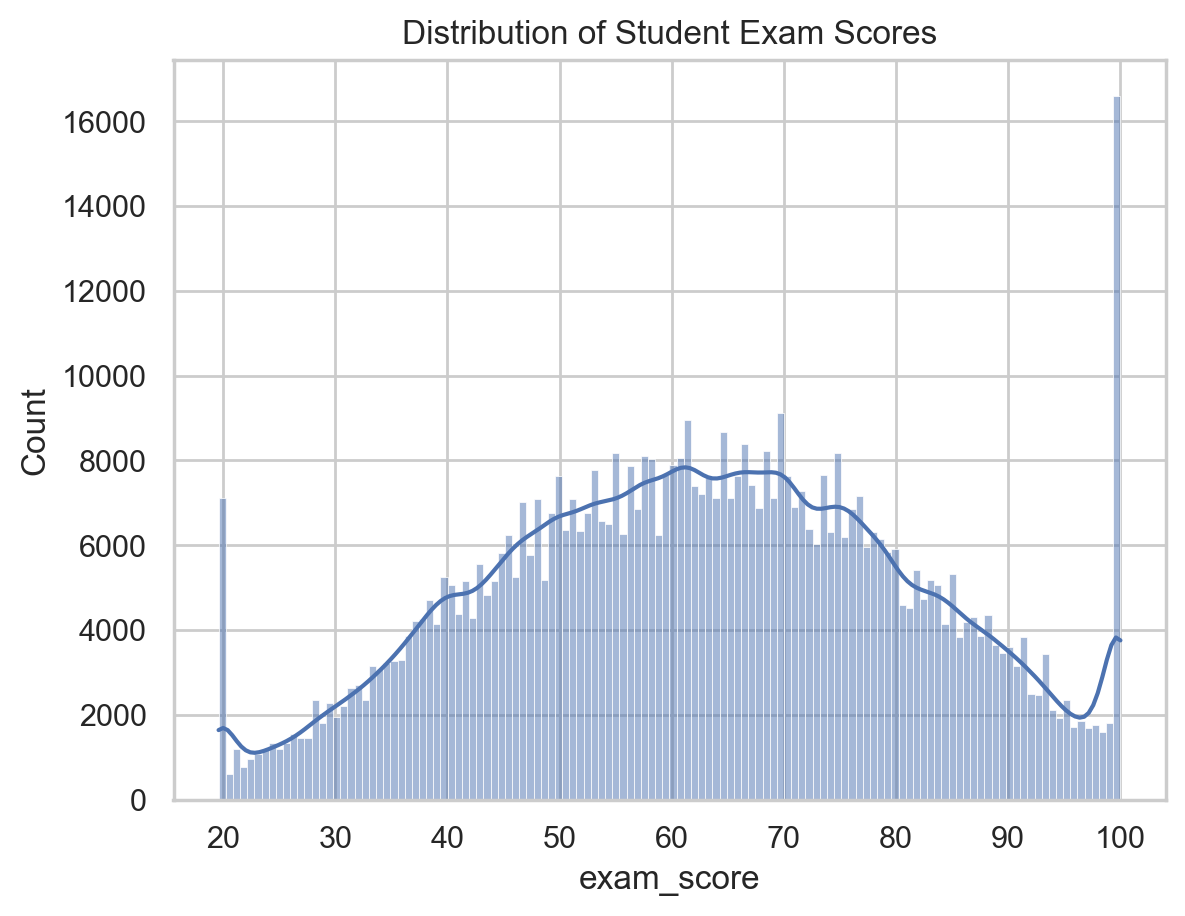

Skewness: -0.04827320083537824


In [8]:
sns.histplot(train['exam_score'], kde=True)
plt.title('Distribution of Student Exam Scores')
plt.show()
print(f"Skewness: {train['exam_score'].skew()}")

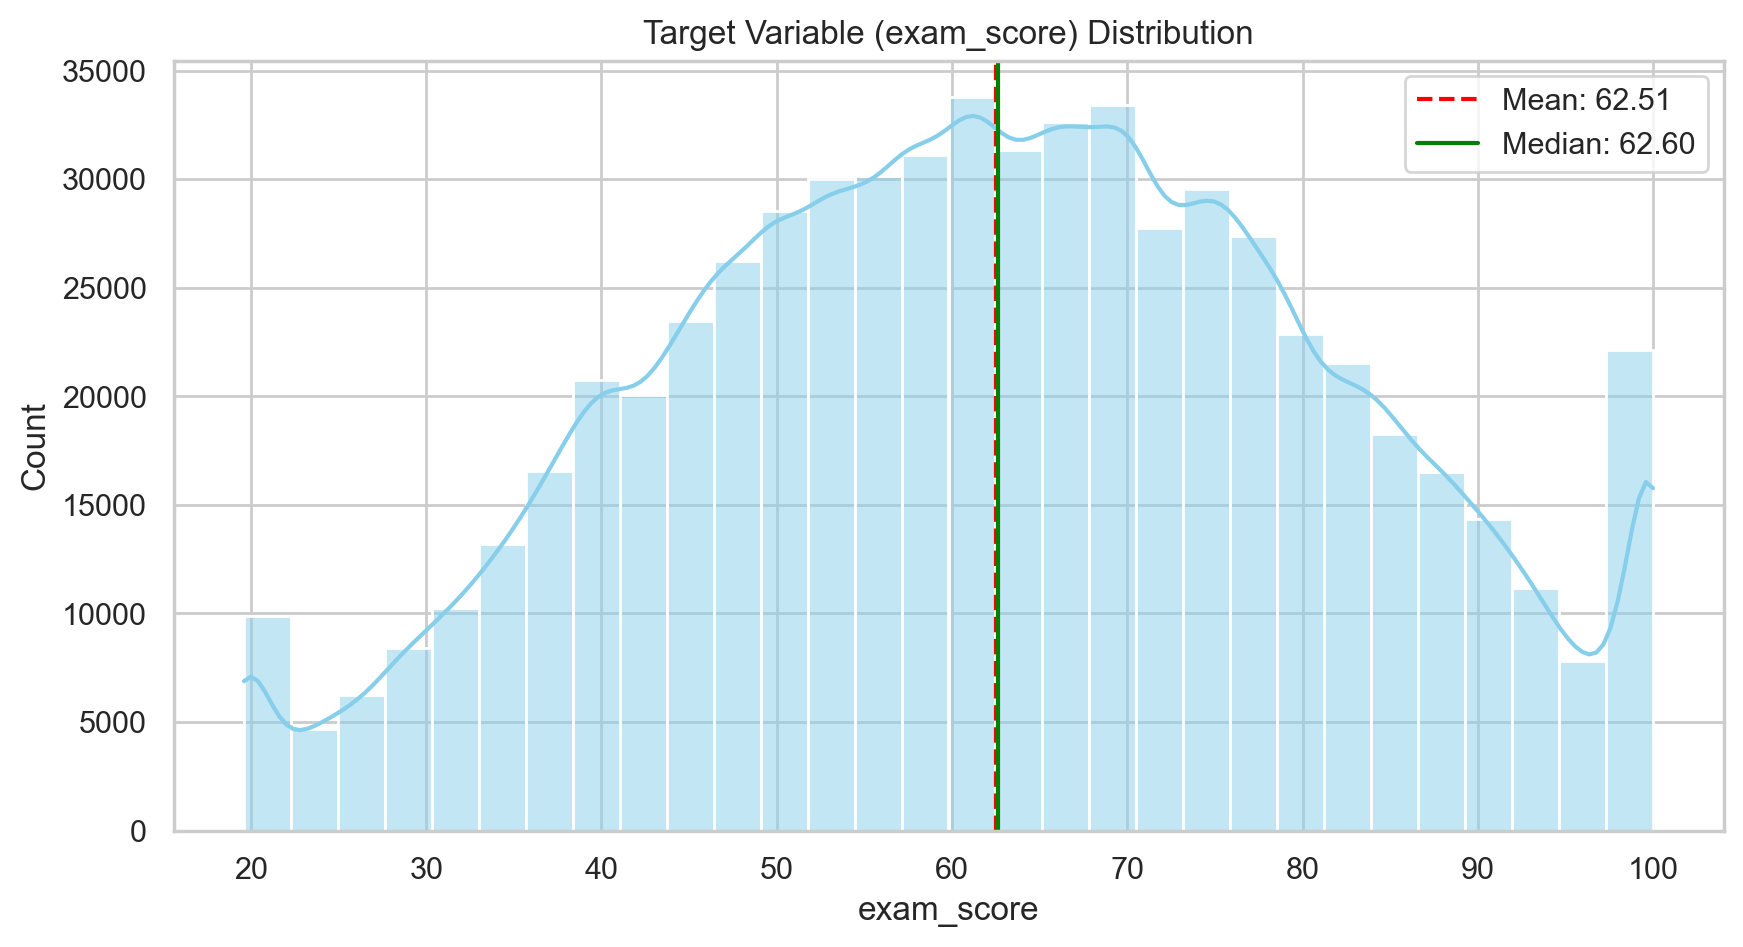

In [9]:
plt.figure(figsize=(10, 5))

sns.histplot(train['exam_score'], kde=True, bins=30, color='skyblue')

plt.axvline(train['exam_score'].mean(), color='red', linestyle='--', label=f'Mean: {train["exam_score"].mean():.2f}')
plt.axvline(train['exam_score'].median(), color='green', linestyle='-', label=f'Median: {train["exam_score"].median():.2f}')

plt.title('Target Variable (exam_score) Distribution')
plt.legend()
plt.show()

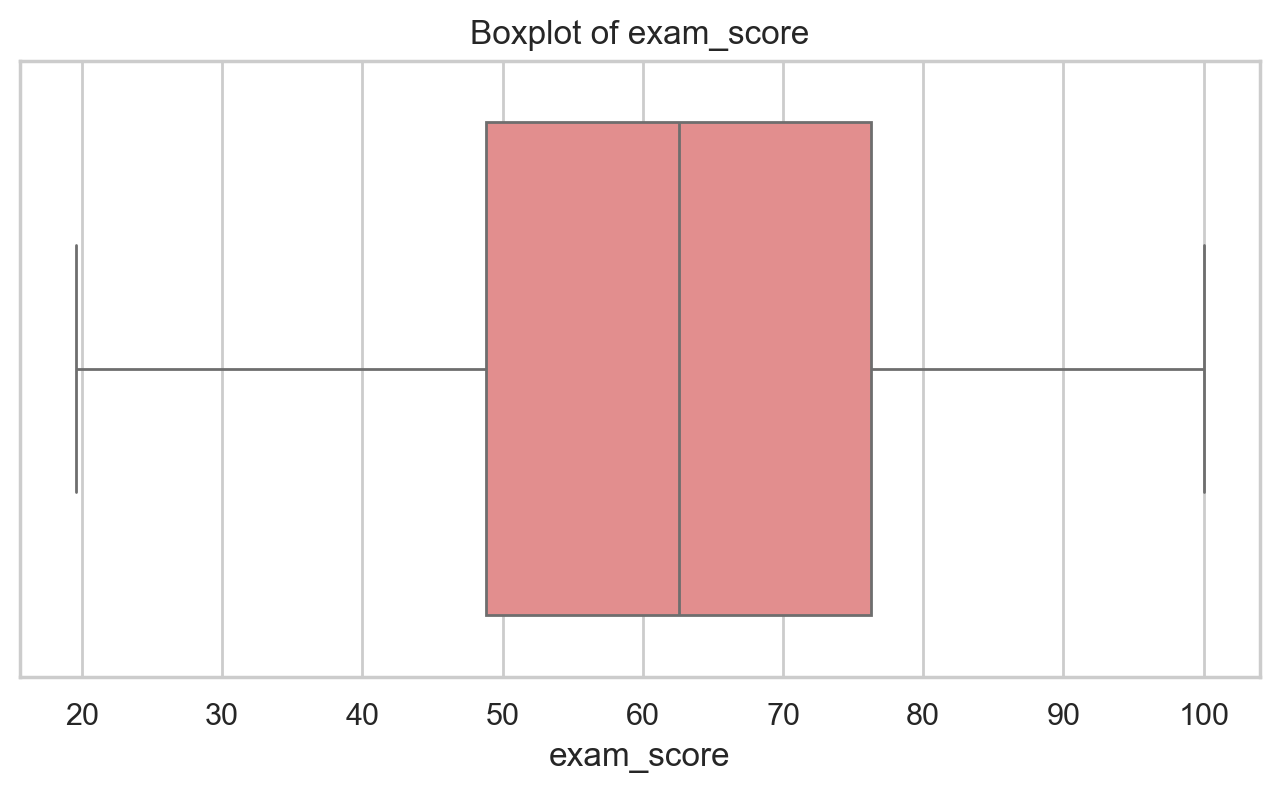

合理的考试分数范围估算为: [7.55, 117.55]
低于该范围的样本数: 0


In [10]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=train['exam_score'], color='lightcoral')
plt.title('Boxplot of exam_score')
plt.show()

# IQR
Q1 = train['exam_score'].quantile(0.25)
Q3 = train['exam_score'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"合理的考试分数范围估算为: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"低于该范围的样本数: {(train['exam_score'] < lower_bound).sum()}")

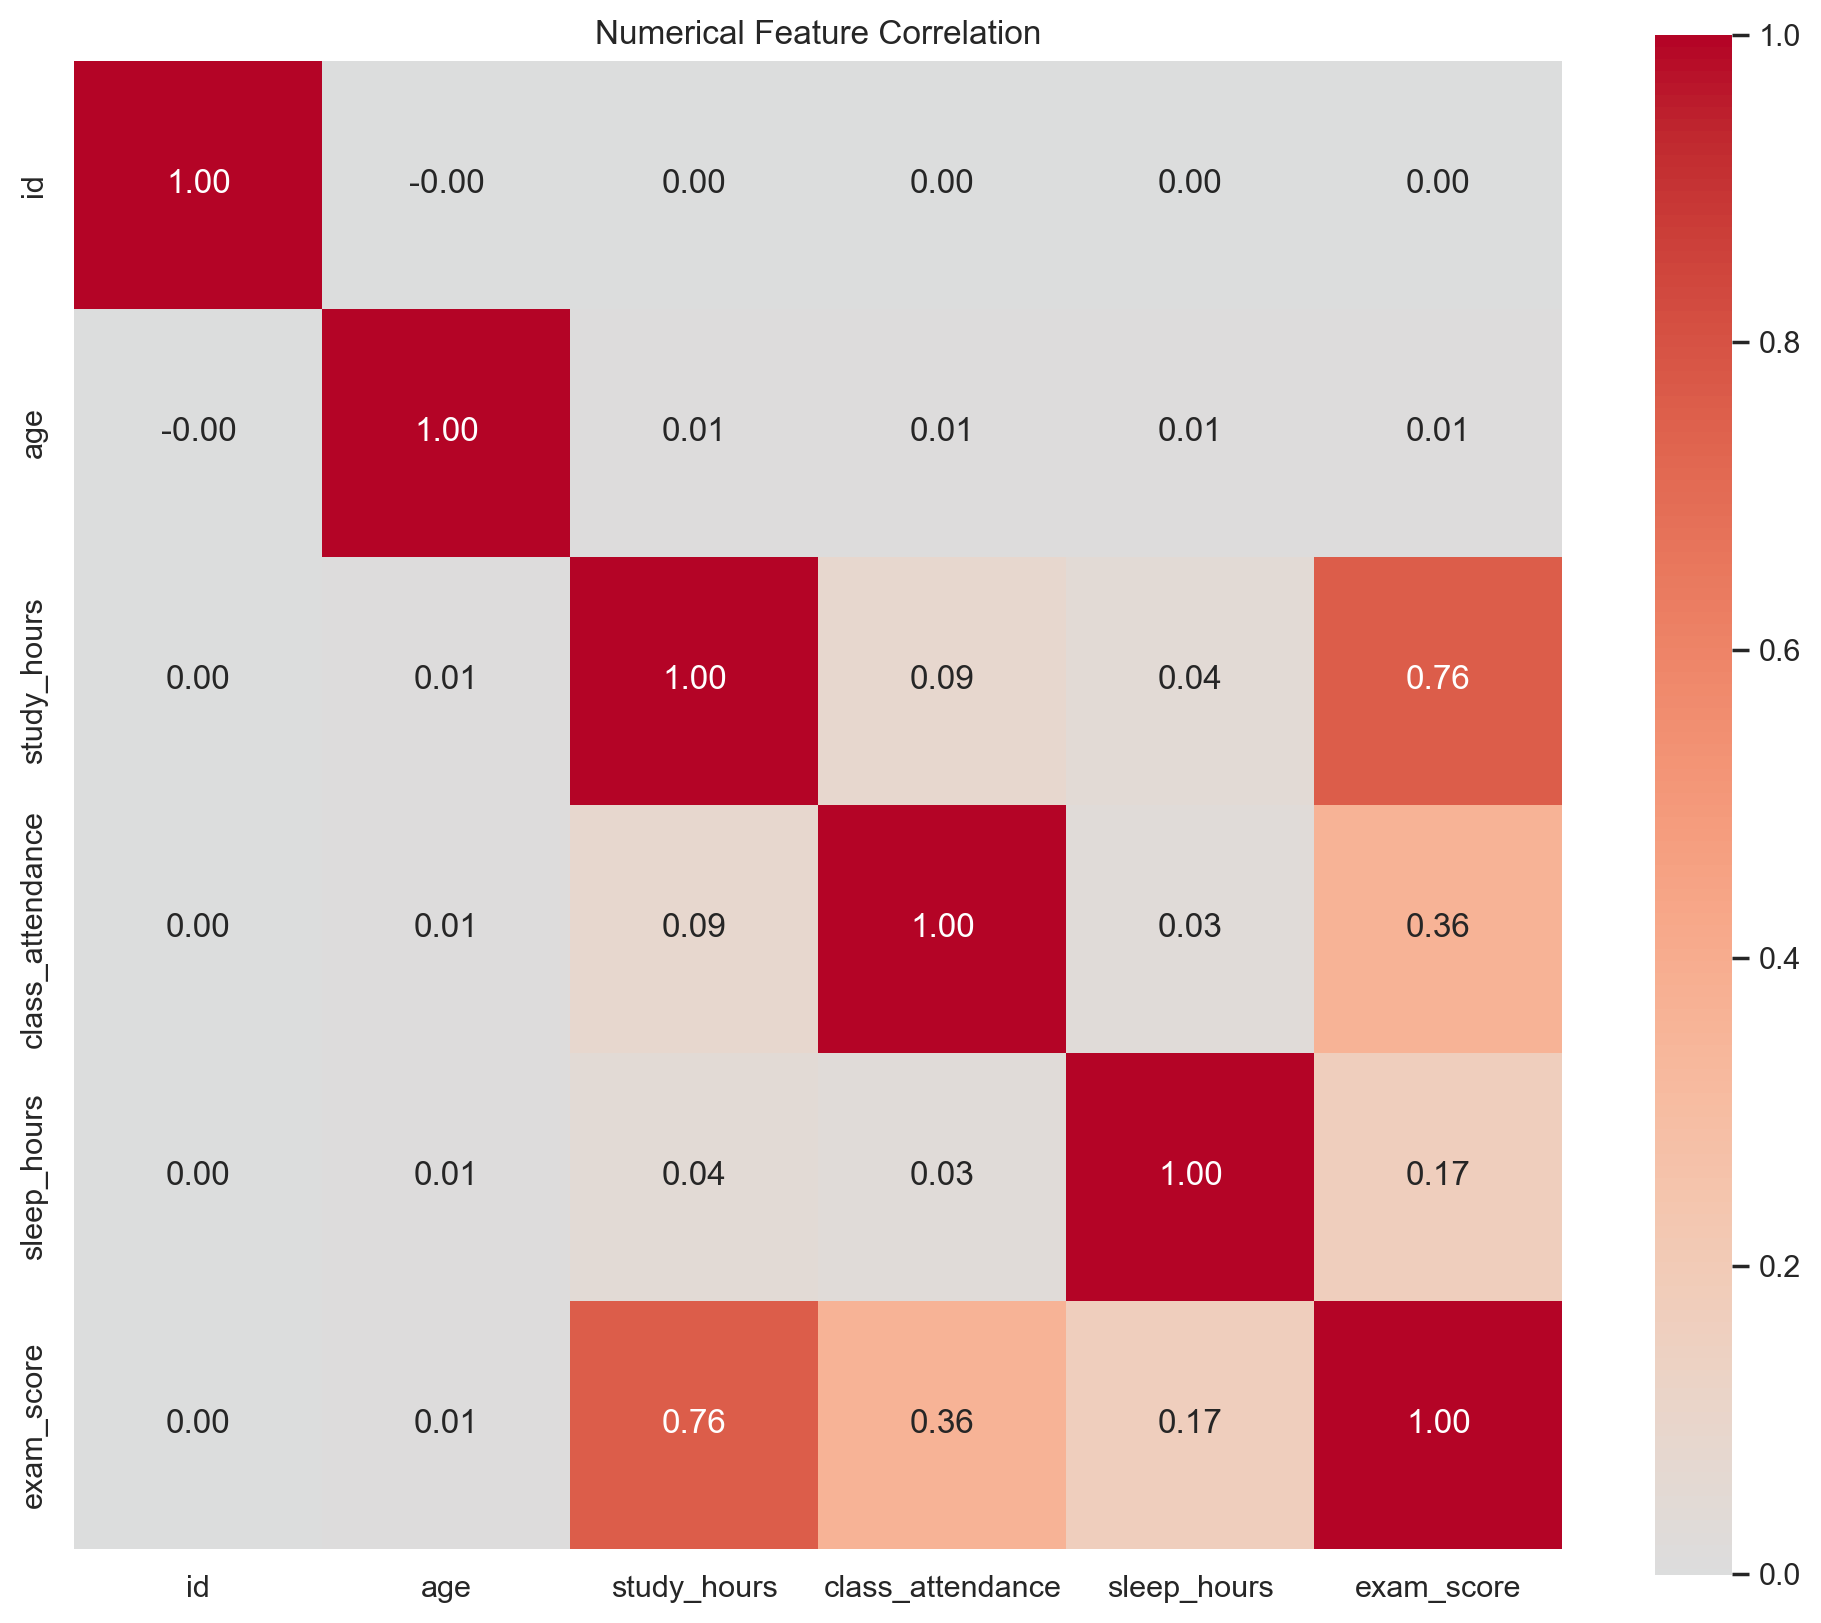

In [11]:
plt.figure(figsize=(12, 10))

# Only number type
numeric_train = train.select_dtypes(include=[np.number])
corr = numeric_train.corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0, square=True)
plt.title('Numerical Feature Correlation')
plt.show()

C:\Users\lucif\AppData\Local\Temp\ipykernel_15092\2970664747.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='internet_access', y='exam_score', data=train, palette='Set2')


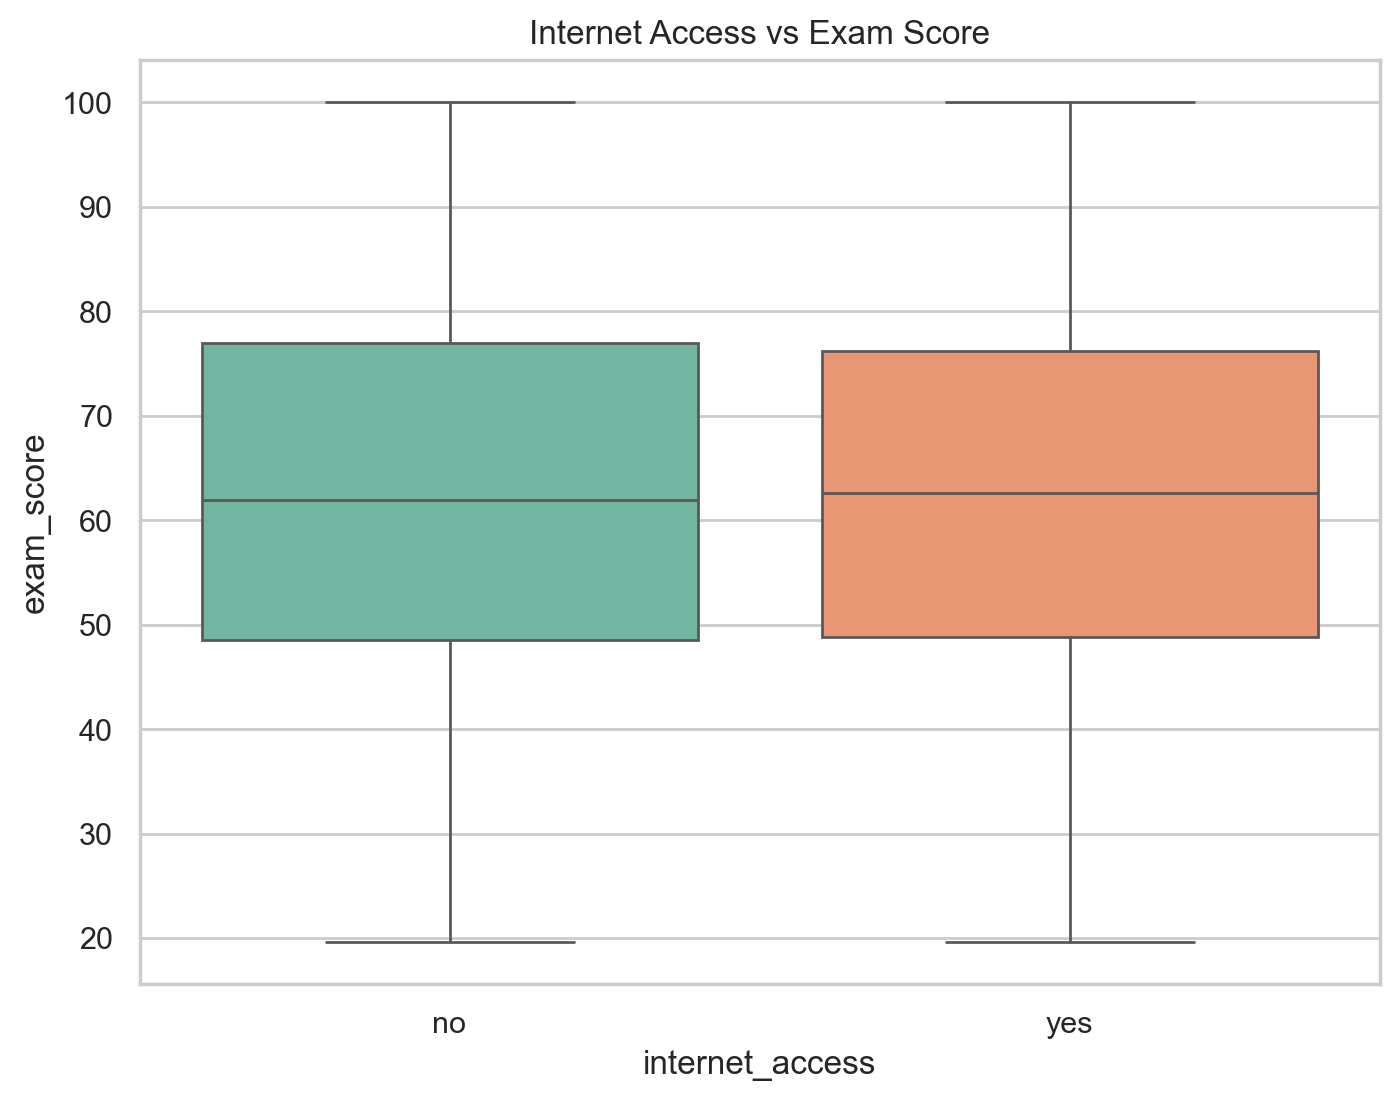

In [12]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='internet_access', y='exam_score', data=train, palette='Set2')
plt.title('Internet Access vs Exam Score')
plt.show()

C:\Users\lucif\AppData\Local\Temp\ipykernel_15092\1654722949.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='exam_difficulty', y='exam_score', data=train,


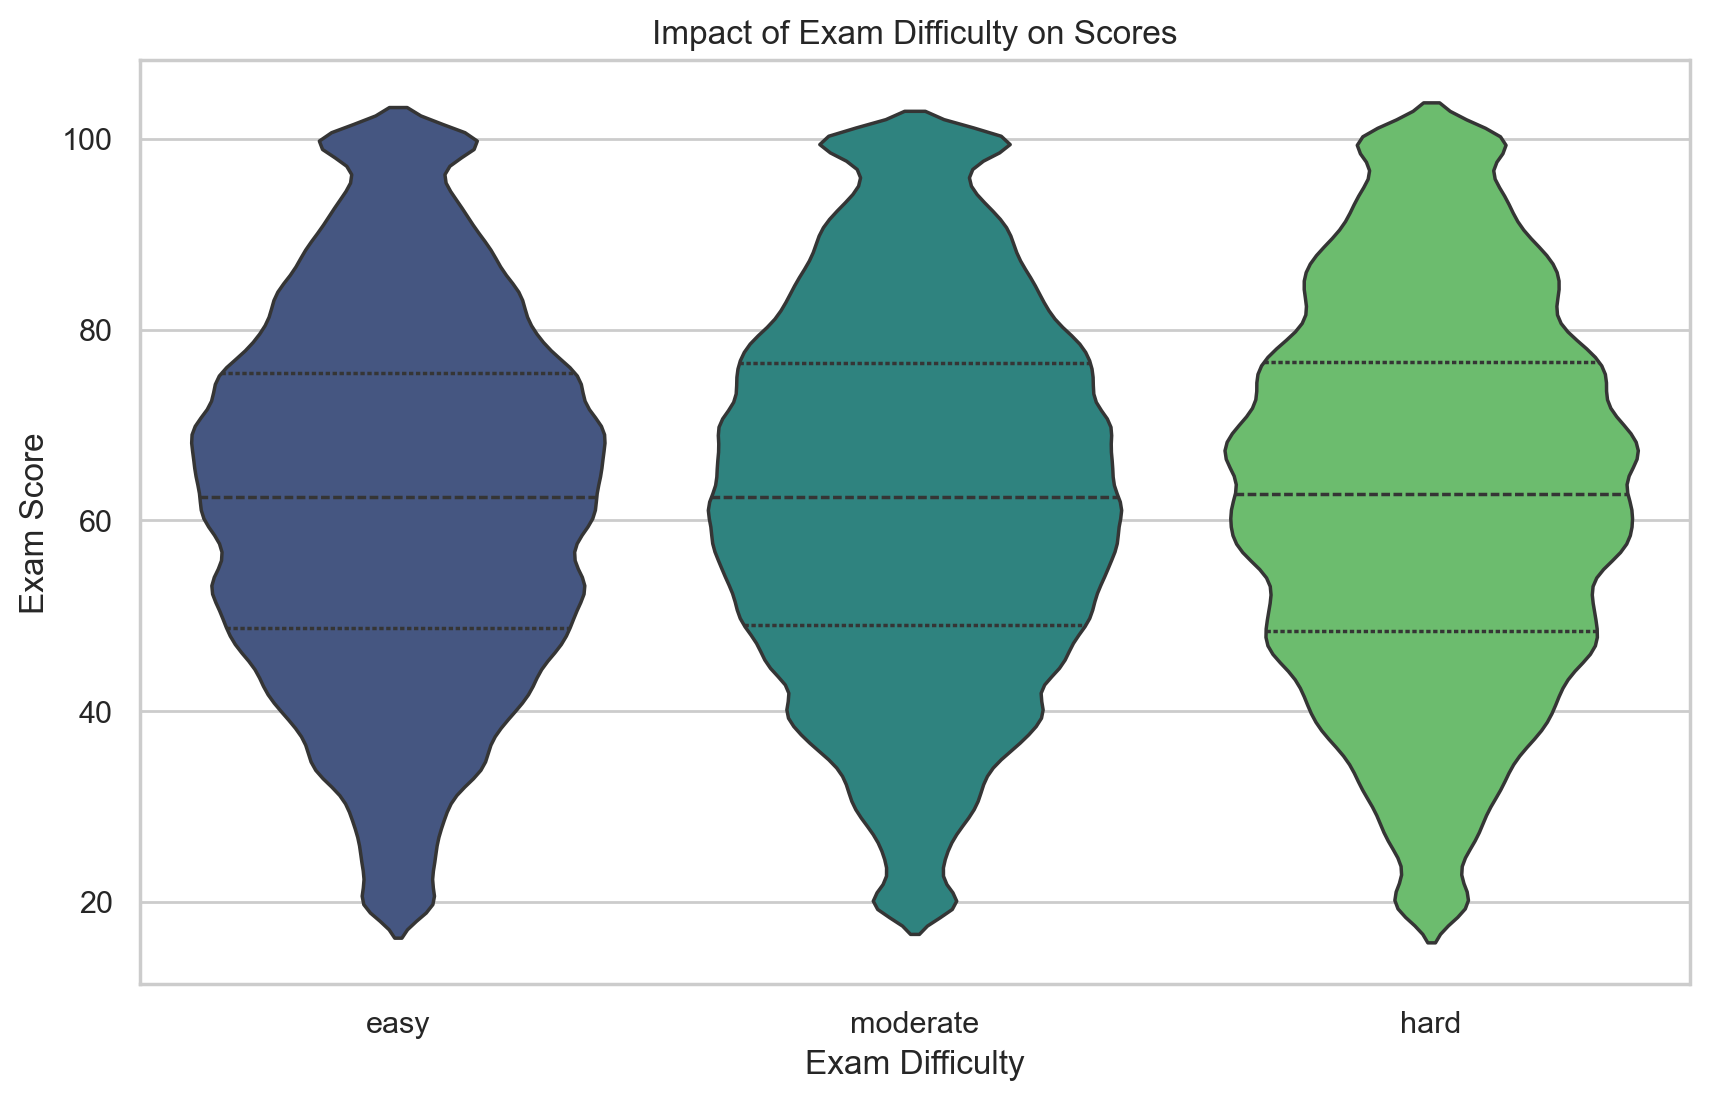

In [16]:
plt.figure(figsize=(10, 6))

difficulty_order = ['easy', 'moderate', 'hard'] 

sns.violinplot(x='exam_difficulty', y='exam_score', data=train, 
               order=difficulty_order, palette='viridis', inner="quartile")

plt.title('Impact of Exam Difficulty on Scores')
plt.xlabel('Exam Difficulty')
plt.ylabel('Exam Score')
plt.show()

In [17]:
# 将睡眠质量转化为数值，以便计算
quality_map = {'poor': 1, 'average': 2, 'good': 3} # 根据你的实际值调整
train['sleep_quality_val'] = train['sleep_quality'].map(quality_map)

# 创造交叉特征
train['sleep_index'] = train['sleep_hours'] * train['sleep_quality_val']

# 验证交叉特征与目标变量的相关性
new_corr = train[['exam_score', 'sleep_hours', 'sleep_index']].corr()
print("睡眠相关特征与分数的对比：\n", new_corr['exam_score'])

睡眠相关特征与分数的对比：
 exam_score    1.000
sleep_hours   0.167
sleep_index   0.279
Name: exam_score, dtype: float64


In [18]:
diff_map = {'easy': 0, 'moderate': 1, 'hard': 2}
train['exam_difficulty_enc'] = train['exam_difficulty'].map(diff_map)

print(train[['exam_difficulty', 'exam_difficulty_enc']].head())

  exam_difficulty  exam_difficulty_enc
0            easy                    0
1        moderate                    1
2        moderate                    1
3        moderate                    1
4            easy                    0


In [23]:
print(train.head())

   id  age   course  study_hours  class_attendance  sleep_hours sleep_quality  \
0   0   21     b.sc        7.910            98.800        4.900       average   
1   1   18  diploma        4.950            94.800        4.700          poor   
2   2   20     b.sc        4.680            92.600        5.800          poor   
3   3   19     b.sc        2.000            49.500        8.300       average   
4   4   23      bca        7.650            86.900        9.600          good   

    study_method facility_rating exam_difficulty  exam_score  \
0  online videos             low            easy      78.300   
1     self-study          medium        moderate      46.700   
2       coaching            high        moderate      99.000   
3    group study            high        moderate      63.900   
4     self-study            high            easy     100.000   

   sleep_quality_val  sleep_index  exam_difficulty_enc  gender_male  \
0                  2        9.800                    0   

In [24]:
facility_map = {'low': 1, 'medium': 2, 'high': 3}
train['facility_rating_num'] = train['facility_rating'].map(facility_map)
test['facility_rating_num'] = test['facility_rating'].map(facility_map)

In [25]:
train = pd.get_dummies(train, columns=['study_method'], prefix='method')
test = pd.get_dummies(test, columns=['study_method'], prefix='method')

In [26]:
print(train.head())

   id  age   course  study_hours  class_attendance  sleep_hours sleep_quality  \
0   0   21     b.sc        7.910            98.800        4.900       average   
1   1   18  diploma        4.950            94.800        4.700          poor   
2   2   20     b.sc        4.680            92.600        5.800          poor   
3   3   19     b.sc        2.000            49.500        8.300       average   
4   4   23      bca        7.650            86.900        9.600          good   

  facility_rating exam_difficulty  exam_score  sleep_quality_val  sleep_index  \
0             low            easy      78.300                  2        9.800   
1          medium        moderate      46.700                  1        4.700   
2            high        moderate      99.000                  1        5.800   
3            high        moderate      63.900                  2       16.600   
4            high            easy     100.000                  3       28.800   

   exam_difficulty_enc  ge